<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------PopOut Game-------
</h1>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------Autores-------
</h1>

<div style="text-align: center; font-family: 'Trebuchet MS', sans-serif;">
    <span style="color: white;">André Xie</span> <span style="color: #FFB6C1;">up202407558</span> &nbsp;&nbsp;|&nbsp;&nbsp;
    <span style="color: white;">Beatriz Morais</span> <span style="color: #FFB6C1;">up202405273</span> &nbsp;&nbsp;|&nbsp;&nbsp;
    <span style="color: white;">Manuel Mota</span> <span style="color: #FFB6C1;">up202403543</span>
</div>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------INTRODUÇÃO-------
</h1>

Este projeto foca-se no desenvolvimento e na otimização de algoritmos de Inteligência Artificial no jogo PopOut, uma variante do clássico Quatro em linha (Connect-4). A principal diferença que distingue o PopOut do jogo clássico, é a possibilidade de, em cada turno, o jogador optar por introduzir uma nova peça no topo de uma das colunas ou remover uma peça da sua própria cor da base. A
inclusão de regras adicionais modifica profundamente a dinâmica da partida, tornando o jogo muito mais complexo e estratégico.


O objetivo principal deste trabalho consiste na implementação e avaliação de algoritmos de tomada de decisão, nomeadamente o **Monte Carlo Tree Search (MCTS)** e as **Árvores de Decisão (Decision Trees)**



<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------IMPORTS-------
</h1>

In [29]:
# ==========================================================
# 1. BIBLIOTECAS PADRÃO (STANDARD)
# ==========================================================
import time
import random

# ==========================================================
# 2. CIÊNCIA DE DADOS E VISUALIZAÇÃO
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML

# ==========================================================
# 3. LÓGICA DO JOGO (LOCAL)
# ==========================================================
from moves import PopOutBoard

# ==========================================================
# 4. VERSÕES DO MCTS (COM APELIDOS)
# ==========================================================
from mcts import mcts as mcts_v1
from mcts2 import mcts as mcts_v2
from mcts3 import mcts as mcts_v3
from mcts4 import mcts as mcts_v4
from mcts5 import mcts as mcts_v5
from mcts6 import get_best_move_mcts as mcts_v6

# ==========================================================
# 5. ÁRVORE DE DECISÃO
# ==========================================================
from ID3_Tree import ID3
from popout_ID3_Tree import carregar_dataset_jogo, stratified_split
from collections import Counter

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------Algoritmos-------
</h1>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST1
</h1>

Esta é a versão clássica e fundamental do Monte Carlo Tree Search. Nesta versão, a fase de simulação (rollout) é puramente aleatória: o algoritmo seleciona jogadas de forma aleatória até atingir um estado terminal (vitória, derrota ou empate). Embora o agente conheça as regras básicas para gerar movimentos válidos, não possui qualquer conhecimento prévio sobre as regras ou estratégias do PopOut. Esta versão serve como o nosso ponto de controlo (baseline), permitindo-nos demonstrar que as otimizações introduzidas nas versões seguintes resultam num impacto estatisticamente positivo na taxa de vitória.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST2
</h1>

Esta versão é uma versão otimizada da MCTS1, foi introduzida uma heuristica simples, mas altamente eficaz, na fase de simulação (rollout). Antes de escolher uma jogada aleatória, o agente inspeciona o tabuleiro para verificar se existe alguma jogada que lhe garanta a vitória imediata. Se for encontrada uma jogada que lhe permita vencer, executa-a. Esta modificação oferece a IA um "instinto ofensivo", mantendo a complexidade computacional baixa no limite de tempo O(n).

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST3
</h1>

Esta variante foca-se na "sobrevivência". Durante o rollout, a IA não procura apenas a vitória, mas também antecipa e simula todas as respostas possíveis do oponente a cada movimento. Se alguma jogada der a chance do adversário ganhar no turno seguinte, a IA classifica-a como insegura e evita jogá-la. Apesar de ser estrategicamente mais robusta, a sua complexidade computacional passa a ser quadrática (O(n^2)), o que torna a pesquisa extremamente lenta e reduz drasticamente o número de iterações que o algoritmo consegue calcular no mesmo espaço de tempo.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST4
</h1>

Esta versão serve como uma ponte de otimização. Reconhecendo o peso computacional do MCTS3, esta versão tenta manter o comportamento defensivo, mas reorganiza o código para evitar padrões e "armadilhas". A grande diferença ocorre no final do algoritmo: após construir a árvore de pesquisa, a IA aplica um "filtro de segurança" direto aos nós filhos da raiz. Mesmo que uma jogada tenha recebido muitas visitas durante as simulações, se ela originar uma derrota imediata, a IA descarta essa ramificação e escolhe a alternativa mais segura. A sua complexidade é O(n).

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST5
</h1>

Esta variante é uma refatorização completa que resolve o dilema entre "Inteligência vs Velocidade". A grande inovação é a extração dos "instintos de ataque e defesa" para fora da árvore de pesquisa: o algoritmo verifica ameaças e vitórias imediatas antes de iniciar o MCTS. Se a IA estiver em risco, ou seja, na próxima jogada pode perder, bloqueia imediatamente sem gastar poder de cálculo. Isto permitiu que o rollout voltasse a ser super rápido (O(n)), escalando as iterações de 150 para mais de 1500 no mesmo período de tempo. Além disso, introduz a limitação de ramificação (max_children) para focar a pesquisa nas colunas centrais e a Temperatura de Abertura, garantindo variabilidade nos primeiros movimentos para gerar datasets mais ricos para o modelo de Árvores de Decisão (ID3).

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST6
</h1>

Nesta versão do Monte Carlo Tree Search, é introduzido a técnica de Paralelização de Raiz (Root Parallelization). Em vez de executar as simulações de forma sequencial, o MCTS6 distribui a carga das simulações por todos os núcleos disponíveis do processador em simultâneo, utilizando o **ProcessPoolExecutor**. Desta forma, o total de iterações é dividido igualmente pelos diferentes núcleos da máquina, permitindo que cada um construa e explore a sua própria sub-árvore de forma totalmente independente. Quando todas as simulações terminarem, o algoritmo recolhe os dados e aplica um sistema de votação combinada, somando o número de visitas que cada jogada válida recebeu em todos os processos. A decisão final recai sobre o movimento que reunir o maior consenso global. Além disso, esta versão herda os "reflexos de sobrevivência" das versões anteriores, avaliando vitórias imediatas e ameaças críticas logo no início do turno, o que poupa poder de cálculo e foca a pesquisa nas jogadas verdadeiramente seguras.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ÁRVORES DE DECISÃO (ID3)
</h1>

Nesta segunda fase do projeto, exploramos uma abordagem baseada em Aprendizagem Automática (*Machine Learning*) através do algoritmo **ID3**. O objetivo é treinar um modelo capaz de prever a melhor jogada, aprendendo os padrões a partir de um *dataset* gerado pelas simulações do nosso melhor agente MCTS.

A implementação deste algoritmo foi feita de raiz e exigiu três adaptações técnicas fundamentais para lidar com a complexidade do jogo PopOut:

*   **Adaptação para Dados Numéricos:** O algoritmo ID3 clássico opera naturalmente com dados categóricos. Como o nosso tabuleiro é representado por números (zeros, uns e dois), o algoritmo foi modificado para calcular dinamicamente pontos de corte (*thresholds*) entre valores. A árvore avalia múltiplos cortes e escolhe aquele que maximiza o **Ganho de Informação** baseado no cálculo da Entropia.
*   **Controlo de Overfitting:** As árvores de decisão tendem a crescer infinitamente até memorizarem o *dataset*, perdendo a capacidade de generalizar. Para evitar este problema, implementámos dois mecanismos de paragem preventiva (Early Stopping): uma profundidade máxima da árvore (`max_depth = 10`) e um número mínimo de amostras necessárias para continuar a dividir os nós (`min_samples = 5`).
*   **Divisão Estratificada (Stratified Split):** Para treinar o modelo, o *dataset* foi dividido em 80% para treino e 20% para teste. Foi programada uma função de divisão estratificada para garantir que a proporção das diferentes jogadas (classes) se mantém perfeitamente equilibrada entre os dois conjuntos de dados, evitando enviesamentos estatísticos.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------AVALIAÇÃO DAS ÁRVORES DE DECISÃO-------
</h1>

In [30]:
# ==========================================================
# TESTE E AVALIAÇÃO DA ÁRVORE DE DECISÃO (ID3)
# ==========================================================

# 1. Carregar o dataset gerado pelo MCTS
# NOTA: Certifica-te que o ficheiro 'dataset.csv' está na mesma pasta
data = carregar_dataset_jogo("dataset.csv")

if data:
    # 2. Split Estratificado (80% Treino, 20% Teste)
    train_data, test_data = stratified_split(data, test_size=0.2)

    # 3. Instanciar o modelo ID3 modificado
    modelo_id3 = ID3()
    
    # 4. Definir os índices dos atributos (tudo menos a última coluna, que é a jogada)
    num_atributos = len(data[0]) - 1 
    indices_atributos = list(range(num_atributos)) 
    
    print("A iniciar o treino da Árvore de Decisão...")
    print(f"Tamanho do Dataset de Treino: {len(train_data)} amostras")
    
    # 5. Treino da Árvore Numérica com controlo de overfitting
    inicio_treino = time.time()
    tree_jogo = modelo_id3.construir(train_data, indices_atributos, max_depth=10, min_samples=5)
    tempo_treino = time.time() - inicio_treino
    
    # 6. Descobrir a jogada mais comum para casos desconhecidos (Plano B)
    todas_as_jogadas = [row[-1] for row in train_data]
    jogada_mais_comum = Counter(todas_as_jogadas).most_common(1)[0][0]

    # 7. Fase de Teste
    print(f"Treino concluído em {tempo_treino:.2f} segundos!")
    print(f"A testar com o conjunto de validação ({len(test_data)} amostras)...")
    
    acertos = 0
    for row in test_data:
        features = row[:-1]
        real = row[-1].strip()

        # Previsão da jogada com base na árvore construída
        previsao = modelo_id3.prever(tree_jogo, features, classe_default=jogada_mais_comum)
        
        if previsao == real:
            acertos += 1

    # 8. Resultados Finais
    precisao = (acertos / len(test_data)) * 100
    
    print("\n" + "="*45)
    print("      RESULTADOS DA ÁRVORE DE DECISÃO")
    print("="*45)
    print(f"Total de Testes: {len(test_data)}")
    print(f"Previsões Corretas: {acertos}")
    print(f"Precisão (Accuracy): {precisao:.2f}%")
    print("="*45)
    
else:
    print("Erro: Ficheiro 'dataset.csv' não encontrado. É necessário gerar os dados primeiro!")

A iniciar o treino da Árvore de Decisão...
Tamanho do Dataset de Treino: 9330 amostras
Treino concluído em 1.52 segundos!
A testar com o conjunto de validação (2339 amostras)...

      RESULTADOS DA ÁRVORE DE DECISÃO
Total de Testes: 2339
Previsões Corretas: 439
Precisão (Accuracy): 18.77%


Após o treino  do modelo, a fase de validação devolveu uma precisão (accuracy) de 18.77%. Este resultado não indica uma falha na aprendizagem do algoritmo, mas sim a limitação inerente à avaliação estática em jogos de alta complexidade como o PopOut.

O MCTS alcança a sua precisão tática porque "viaja no tempo", simulando o jogo até ao fim antes de agir. A Árvore de Decisão, por outro lado, é forçada a decidir com base numa única imagem estática do tabuleiro. Além disso, a métrica de accuracy exige uma correspondência exata; num jogo onde frequentemente existem duas ou três jogadas igualmente fortes, se a Árvore escolher o "Plano B" em vez do "Plano A" escolhido pelo MCTS no dataset, a previsão é marcada como incorreta. Ainda assim, ao superar a taxa matemática de puro acaso (num jogo com até 14 decisões por turno), o ID3 demonstra que conseguiu mapear com sucesso algumas regras básicas de ataque e defesa, mesmo sem a capacidade de calcular cenários futuros.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------Simulação de jogos (Código)-------
</h1>

In [ ]:
# Lista global para guardar o histórico de todos os torneios realizados
historico_resultados = []
    
def simular_torneio(nome_ia1, func_ia1, iter_ia1, nome_ia2, func_ia2, iter_ia2, num_jogos=10):
    """
    Simula um torneio entre duas IAs (ex: diferentes versões do MCTS).
    Alterna qual IA começa a jogar para garantir que o torneio é justo.
    """
    # Inicialização dos contadores de vitórias e empates
    vitorias_ia1, vitorias_ia2, empates = 0, 0, 0
    total_jogadas = 0
 
    # Variáveis para métricas de tempo (para calcular a média de tempo por jogada)
    tempo_acumulado_ia1 = 0
    tempo_acumulado_ia2 = 0
    decisoes_ia1 = 0
    decisoes_ia2 = 0
    
    print(f"A iniciar torneio: {nome_ia1} ({iter_ia1} iters) vs {nome_ia2} ({iter_ia2} iters)")
    print(f"Configuração: {num_jogos} jogos\n")
    
    # Loop principal que corre o número de jogos definidos (num_jogos)
    for i in range(num_jogos):
        # Inicializa o tabuleiro do PopOut vazio para um novo jogo
        board = PopOutBoard()
        jogadas_neste_jogo = 0
        
        # Mapeamento dinâmico para garantir que a IA certa usa as iterações certas
        # Se i for par, a IA 1 joga como Player 1. Se for ímpar, a IA 2 joga como Player 1.
        if i % 2 == 0:
            ia_p1, iters_p1 = func_ia1, iter_ia1
            ia_p2, iters_p2 = func_ia2, iter_ia2
        else:
            ia_p1, iters_p1 = func_ia2, iter_ia2
            ia_p2, iters_p2 = func_ia1, iter_ia1
        
        # Loop do jogo: continua a pedir jogadas até haver um vencedor ou empate
        while not board.is_terminal():
            # Marca o momento exato antes da IA começar a "pensar"
            inicio_pensamento = time.time()
            
            # Turno do Jogador 1
            if board.current_player == 1:
                no = ia_p1(board, iterations=iters_p1) 
                duracao = time.time() - inicio_pensamento
                
                # Atribui o tempo à IA correta, sabendo quem está a jogar como Player 1 neste jogo
                if i % 2 == 0:
                    tempo_acumulado_ia1 += duracao
                    decisoes_ia1 += 1
                else:
                    tempo_acumulado_ia2 += duracao
                    decisoes_ia2 += 1
                    
            # Turno do Jogador 2
            else:
                no = ia_p2(board, iterations=iters_p2)
                duracao = time.time() - inicio_pensamento
                
                # Atribui o tempo à IA correta, sabendo quem está a jogar como Player 2 neste jogo
                if i % 2 == 0:
                    tempo_acumulado_ia2 += duracao
                    decisoes_ia2 += 1
                else:
                    tempo_acumulado_ia1 += duracao
                    decisoes_ia1 += 1
            
            # Compatibilidade com MCTS6Result ou Tuplo (extrai a jogada do nó retornado)
            move = no.move if hasattr(no, 'move') else no
            
            # Aplica a jogada no tabuleiro e atualiza o estado do jogo
            board = board.apply_move(move)
            jogadas_neste_jogo += 1
            
        # O jogo terminou. Verifica quem venceu (1 = Player 1, 2 = Player 2)
        vencedor = board.get_winner()
        
        # Regista a vitória para a IA correspondente com base no mapeamento inicial
        if vencedor == 1:
            if i % 2 == 0: vitorias_ia1 += 1
            else: vitorias_ia2 += 1
        elif vencedor == 2:
            if i % 2 == 0: vitorias_ia2 += 1
            else: vitorias_ia1 += 1
        else:
            empates += 1
        
        # Acumula as jogadas deste jogo no total do torneio
        total_jogadas += jogadas_neste_jogo

        if (i + 1) % 5 == 0 or i == 0:
            print(f"Progresso: Jogo {i+1}/{num_jogos} concluído.")
        
    media_ia1 = (tempo_acumulado_ia1 / decisoes_ia1) if decisoes_ia1 > 0 else 0
    media_ia2 = (tempo_acumulado_ia2 / decisoes_ia2) if decisoes_ia2 > 0 else 0

    historico_resultados.append({
        "ia1": nome_ia1, "iter_ia1": iter_ia1,
        "ia2": nome_ia2, "iter_ia2": iter_ia2,
        "v_ia1": vitorias_ia1, "v_ia2": vitorias_ia2, 
        "empates": empates,
        "tempo_ia1": media_ia1, "tempo_ia2": media_ia2,
        "total_jogadas": total_jogadas
    })
    
    print("\n" + "="*44)
    print("      RESULTADOS FINAIS DE PERFORMANCE")
    print("="*44)
    print(f"{nome_ia1} ({iter_ia1} iters): {vitorias_ia1} vitórias")
    print(f"{nome_ia2} ({iter_ia2} iters): {vitorias_ia2} vitórias")
    print(f"Empates: {empates}")
    print("-" * 44)
    print(f"Tempo médio/jogada {nome_ia1}: {media_ia1:.4f}s")
    print(f"Tempo médio/jogada {nome_ia2}: {media_ia2:.4f}s")
    print(f"Total de jogadas: {total_jogadas}")
    print(f"Média de jogadas/jogo: {total_jogadas/num_jogos:.1f}")
    print("="*44)
    
    df_backup = pd.DataFrame(historico_resultados)
    df_backup.to_csv("backup_resultados_mcts.csv", index=False)

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS1 vs MCTS2
</h1>

In [3]:
# ==========================================
# TESTAR MCTS v1 vs MCTS v2
# ==========================================
simular_torneio( nome_ia1="MCTS v1", func_ia1=mcts_v1, iter_ia1=1000, nome_ia2="MCTS v2", func_ia2=mcts_v2, iter_ia2=1000)

A iniciar torneio: MCTS v1 (1000 iters) vs MCTS v2 (1000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v1 (1000 iters): 10 vitórias
MCTS v2 (1000 iters): 0 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v1: 1.5217s
Tempo médio/jogada MCTS v2: 2.8797s
Total de jogadas: 295
Média de jogadas/jogo: 29.5


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS1 vs MCTS3
</h1>

In [4]:
# ==========================================
# TESTAR MCTS v1 vs MCTS v3
# ==========================================
simular_torneio(nome_ia1="MCTS v1", func_ia1=mcts_v1, iter_ia1=1000,  nome_ia2="MCTS v3", func_ia2=mcts_v3, iter_ia2=1000)

A iniciar torneio: MCTS v1 (1000 iters) vs MCTS v3 (1000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v1 (1000 iters): 5 vitórias
MCTS v3 (1000 iters): 5 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v1: 1.5081s
Tempo médio/jogada MCTS v3: 120.5017s
Total de jogadas: 138
Média de jogadas/jogo: 13.8


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS1 vs MCTS4
</h1>

In [5]:
# ==========================================
# TESTAR MCTS v1 vs MCTS v4
# ==========================================
simular_torneio(nome_ia1="MCTS v1", func_ia1=mcts_v1, iter_ia1=1000,  nome_ia2="MCTS v4", func_ia2=mcts_v4, iter_ia2=1000)

A iniciar torneio: MCTS v1 (1000 iters) vs MCTS v4 (1000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v1 (1000 iters): 1 vitórias
MCTS v4 (1000 iters): 9 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v1: 1.0756s
Tempo médio/jogada MCTS v4: 16.9512s
Total de jogadas: 205
Média de jogadas/jogo: 20.5


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS1 vs MCTS5
</h1>

In [6]:
# ==========================================
# TESTAR MCTS v1 vs MCTS v5
# ==========================================
simular_torneio(nome_ia1="MCTS v1", func_ia1=mcts_v1, iter_ia1=1000,  nome_ia2="MCTS v5", func_ia2=mcts_v5, iter_ia2=1500)

A iniciar torneio: MCTS v1 (1000 iters) vs MCTS v5 (1500 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v1 (1000 iters): 0 vitórias
MCTS v5 (1500 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v1: 1.4485s
Tempo médio/jogada MCTS v5: 3.6910s
Total de jogadas: 109
Média de jogadas/jogo: 10.9


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS1 vs MCTS6
</h1>

In [7]:
# ==========================================
# TESTAR MCTS v1 vs MCTS v6
# ==========================================
simular_torneio(nome_ia1="MCTS v1", func_ia1=mcts_v1, iter_ia1=1000,  nome_ia2="MCTS v6", func_ia2=mcts_v6, iter_ia2=6000)

A iniciar torneio: MCTS v1 (1000 iters) vs MCTS v6 (6000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v1 (1000 iters): 0 vitórias
MCTS v6 (6000 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v1: 1.5640s
Tempo médio/jogada MCTS v6: 9.2010s
Total de jogadas: 129
Média de jogadas/jogo: 12.9


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS2 vs MCTS3
</h1>

In [8]:
# ==========================================
# TESTAR MCTS v2 vs MCTS v3
# ==========================================
simular_torneio(nome_ia1="MCTS v2", func_ia1=mcts_v2, iter_ia1=1000, nome_ia2="MCTS v3", func_ia2=mcts_v3, iter_ia2=1000)

A iniciar torneio: MCTS v2 (1000 iters) vs MCTS v3 (1000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v2 (1000 iters): 0 vitórias
MCTS v3 (1000 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v2: 2.4717s
Tempo médio/jogada MCTS v3: 95.3739s
Total de jogadas: 295
Média de jogadas/jogo: 29.5


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS2 vs MCTS4
</h1>

In [9]:
# ==========================================
# TESTAR MCTS v2 vs MCTS v4
# ==========================================
simular_torneio(nome_ia1="MCTS v2", func_ia1=mcts_v2, iter_ia1=1000, nome_ia2="MCTS v4", func_ia2=mcts_v4, iter_ia2=1000)

A iniciar torneio: MCTS v2 (1000 iters) vs MCTS v4 (1000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v2 (1000 iters): 0 vitórias
MCTS v4 (1000 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v2: 2.7682s
Tempo médio/jogada MCTS v4: 25.9371s
Total de jogadas: 271
Média de jogadas/jogo: 27.1


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS2 vs MCTS5
</h1>

In [10]:
# ==========================================
# TESTAR MCTS v2 vs MCTS v5
# ==========================================
simular_torneio(nome_ia1="MCTS v2", func_ia1=mcts_v2, iter_ia1=1000, nome_ia2="MCTS v5", func_ia2=mcts_v5, iter_ia2=1500)

A iniciar torneio: MCTS v2 (1000 iters) vs MCTS v5 (1500 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v2 (1000 iters): 0 vitórias
MCTS v5 (1500 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v2: 2.7382s
Tempo médio/jogada MCTS v5: 3.4047s
Total de jogadas: 191
Média de jogadas/jogo: 19.1


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS2 vs MCTS6
</h1>

In [11]:
# ==========================================
# TESTAR MCTS v2 vs MCTS v6
# ==========================================
simular_torneio(nome_ia1="MCTS v2", func_ia1=mcts_v2, iter_ia1=1000, nome_ia2="MCTS v6", func_ia2=mcts_v6, iter_ia2=6000)

A iniciar torneio: MCTS v2 (1000 iters) vs MCTS v6 (6000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v2 (1000 iters): 0 vitórias
MCTS v6 (6000 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v2: 2.3650s
Tempo médio/jogada MCTS v6: 7.0040s
Total de jogadas: 390
Média de jogadas/jogo: 39.0


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS3 vs MCTS4
</h1>

In [12]:
# ==========================================
# TESTAR MCTS v3 vs MCTS v4
# ==========================================
simular_torneio(nome_ia1="MCTS v3", func_ia1=mcts_v3, iter_ia1=1000, nome_ia2="MCTS v4", func_ia2=mcts_v4, iter_ia2=1000)

A iniciar torneio: MCTS v3 (1000 iters) vs MCTS v4 (1000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v3 (1000 iters): 1 vitórias
MCTS v4 (1000 iters): 9 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v3: 67.8085s
Tempo médio/jogada MCTS v4: 13.7338s
Total de jogadas: 207
Média de jogadas/jogo: 20.7


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS3 vs MCTS5
</h1>

In [13]:
# ==========================================
# TESTAR MCTS v3 vs MCTS v5
# ==========================================
simular_torneio(nome_ia1="MCTS v3", func_ia1=mcts_v3, iter_ia1=1000, nome_ia2="MCTS v5", func_ia2=mcts_v5, iter_ia2=1500)

A iniciar torneio: MCTS v3 (1000 iters) vs MCTS v5 (1500 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v3 (1000 iters): 0 vitórias
MCTS v5 (1500 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v3: 104.8589s
Tempo médio/jogada MCTS v5: 3.5793s
Total de jogadas: 132
Média de jogadas/jogo: 13.2


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS3 vs MCTS6
</h1>

In [14]:
# ==========================================
# TESTAR MCTS v3 vs MCTS v6
# ==========================================
simular_torneio(nome_ia1="MCTS v3", func_ia1=mcts_v3, iter_ia1=1000, nome_ia2="MCTS v6", func_ia2=mcts_v6, iter_ia2=6000)

A iniciar torneio: MCTS v3 (1000 iters) vs MCTS v6 (6000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v3 (1000 iters): 0 vitórias
MCTS v6 (6000 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v3: 95.9738s
Tempo médio/jogada MCTS v6: 8.2888s
Total de jogadas: 135
Média de jogadas/jogo: 13.5


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS4 vs MCTS5
</h1>

In [15]:
# ==========================================
# TESTAR MCTS v4 vs MCTS v5
# ==========================================
simular_torneio(nome_ia1="MCTS v4", func_ia1=mcts_v4, iter_ia1=1000, nome_ia2="MCTS v5", func_ia2=mcts_v5, iter_ia2=1500)

A iniciar torneio: MCTS v4 (1000 iters) vs MCTS v5 (1500 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v4 (1000 iters): 0 vitórias
MCTS v5 (1500 iters): 10 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v4: 17.2527s
Tempo médio/jogada MCTS v5: 3.1544s
Total de jogadas: 231
Média de jogadas/jogo: 23.1


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS4 vs MCTS6
</h1>

In [16]:
# ==========================================
# TESTAR MCTS v4 vs MCTS v6
# ==========================================
simular_torneio(nome_ia1="MCTS v4", func_ia1=mcts_v4, iter_ia1=1000, nome_ia2="MCTS v6", func_ia2=mcts_v6, iter_ia2=6000)

A iniciar torneio: MCTS v4 (1000 iters) vs MCTS v6 (6000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v4 (1000 iters): 1 vitórias
MCTS v6 (6000 iters): 9 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v4: 13.3555s
Tempo médio/jogada MCTS v6: 5.8061s
Total de jogadas: 408
Média de jogadas/jogo: 40.8


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS5 vs MCTS6
</h1>

In [17]:
# ==========================================
# TESTAR MCTS v5 vs MCTS v6
# ==========================================
simular_torneio(nome_ia1="MCTS v5", func_ia1=mcts_v5, iter_ia1=1500, nome_ia2="MCTS v6", func_ia2=mcts_v6, iter_ia2=6000)

A iniciar torneio: MCTS v5 (1500 iters) vs MCTS v6 (6000 iters)
Configuração: 10 jogos

Progresso: Jogo 1/10 concluído.
Progresso: Jogo 5/10 concluído.
Progresso: Jogo 10/10 concluído.

      RESULTADOS FINAIS DE PERFORMANCE
MCTS v5 (1500 iters): 10 vitórias
MCTS v6 (6000 iters): 0 vitórias
Empates: 0
--------------------------------------------
Tempo médio/jogada MCTS v5: 2.5154s
Tempo médio/jogada MCTS v6: 5.6386s
Total de jogadas: 248
Média de jogadas/jogo: 24.8


<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------ANÁLISE DE DADOS-------
</h1>



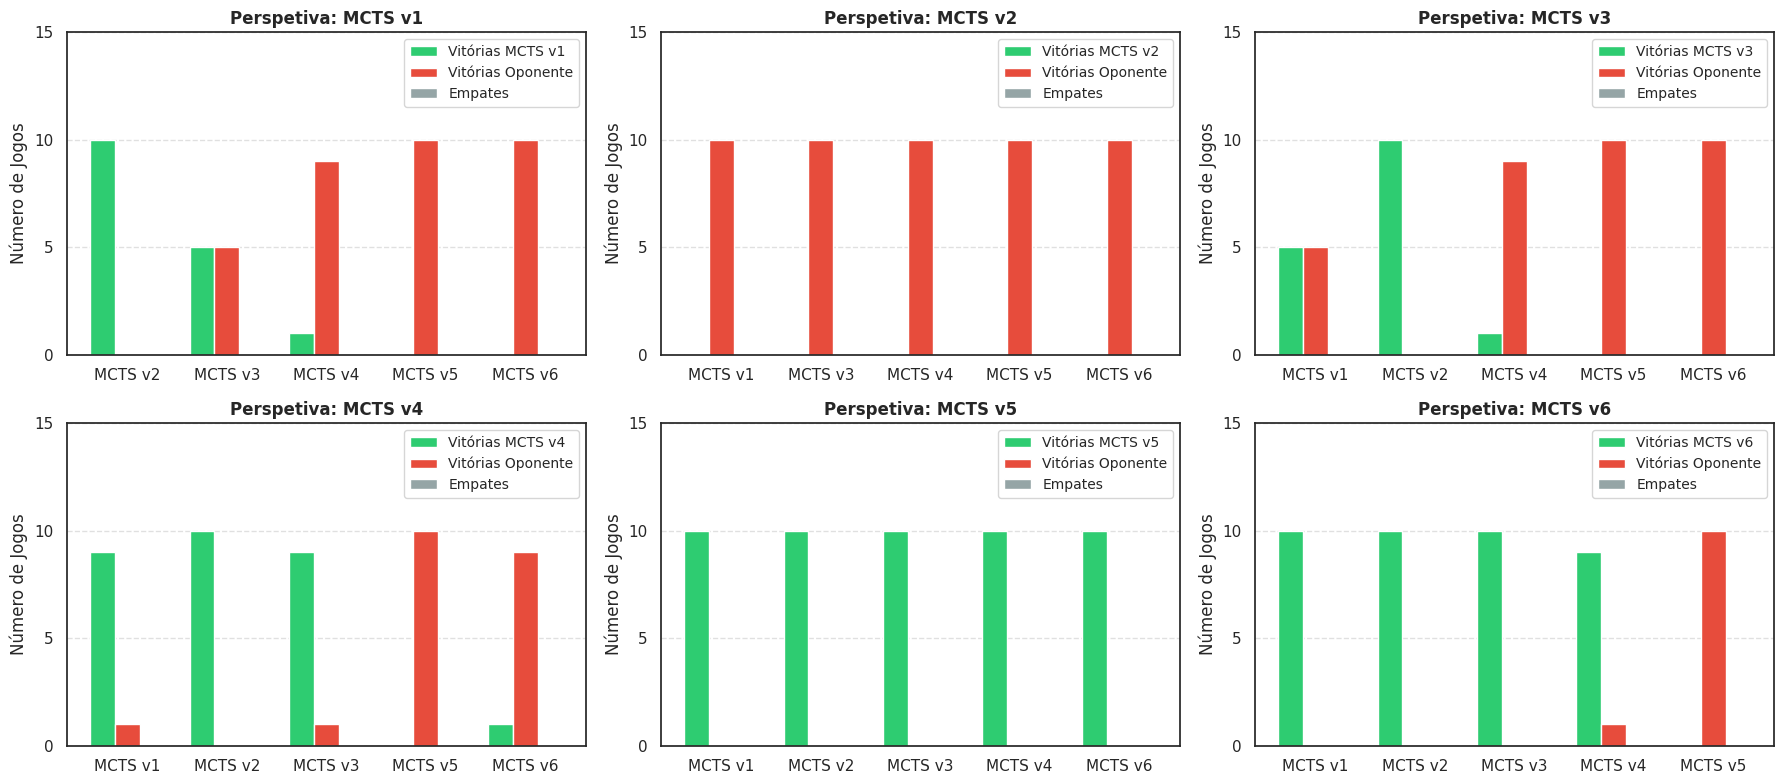

In [26]:
def gerar_graficos_confrontos(resultados):
    if not resultados:
        print("Sem dados para gerar gráficos. Corre alguns torneios primeiro!")
        return

    # 1. Identificar TODAS as IAs
    todas_ias = sorted(list(set(r['ia1'] for r in resultados) | set(r['ia2'] for r in resultados)))
    num_ias = len(todas_ias)
    
    # 2. Configurar a grelha (2 colunas)
    cols = 3
    rows = (num_ias + 2) // 3  # Calcula as linhas necessárias
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
    axes = axes.flatten() # Transforma a matriz de eixos numa lista para iterar facilmente

    for i, ia_principal in enumerate(todas_ias):
        ax = axes[i]
        oponentes, v_principal, v_oponente, empates = [], [], [], []
        
        for r in resultados:
            if r['ia1'] == ia_principal:
                oponentes.append(r['ia2'])
                v_principal.append(r['v_ia1'])
                v_oponente.append(r['v_ia2'])
                empates.append(r['empates'])
            elif r['ia2'] == ia_principal:
                oponentes.append(r['ia1'])
                v_principal.append(r['v_ia2'])
                v_oponente.append(r['v_ia1'])
                empates.append(r['empates'])
        
        if not oponentes:
            ax.axis('off') # Esconde o gráfico se não houver dados
            continue

        x = np.arange(len(oponentes))
        width = 0.25 
        
        ax.bar(x - width, v_principal, width, label=f'Vitórias {ia_principal}', color='#2ecc71')
        ax.bar(x, v_oponente, width, label='Vitórias Oponente', color='#e74c3c')
        ax.bar(x + width, empates, width, label='Empates', color='#95a5a6')
        
        # --- Modificação da Escala (5 em 5) ---
        max_jogos = 30 # Como fazes torneios de 30, fixamos ou calculamos o máximo
        ax.set_yticks(np.arange(0, 16, 5))
        
        ax.set_title(f'Perspetiva: {ia_principal}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Número de Jogos')
        ax.set_xticks(x)
        ax.set_xticklabels(oponentes)
        ax.legend(fontsize='small')
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Esconder subplots vazios (se o número de IAs for ímpar)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Chamar a função
gerar_graficos_confrontos(historico_resultados)

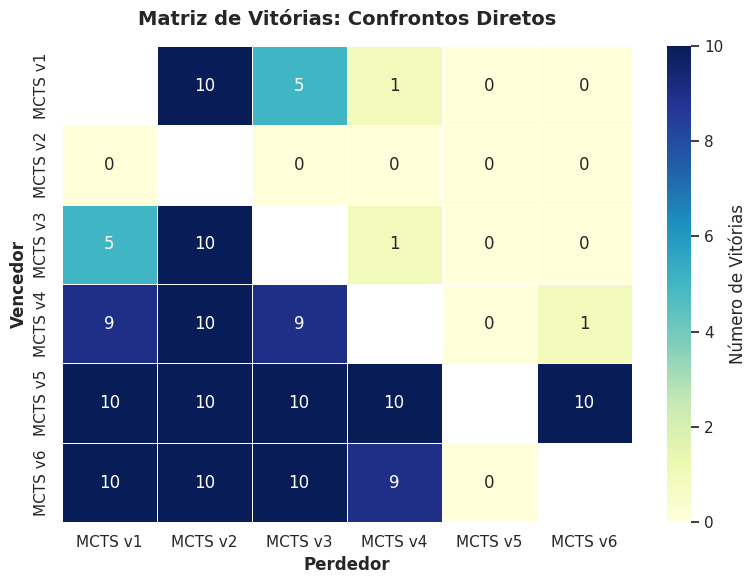

In [19]:
# =============================================================
# CÉLULA: MATRIZ DE CONFRONTOS DIRETOS (HEATMAP DINÂMICO)
# =============================================================
def gerar_heatmap(resultados):
    if not resultados:
        return
        
    ias = sorted(list(set(r['ia1'] for r in resultados) | set(r['ia2'] for r in resultados)))
    df_cm = pd.DataFrame(0, index=ias, columns=ias)
    
    for r in resultados:
        ia1, ia2 = r['ia1'], r['ia2']
        df_cm.loc[ia1, ia2] = r['v_ia1']
        df_cm.loc[ia2, ia1] = r['v_ia2']

    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")
    
    # Desenhar o Heatmap
    ax = sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'Número de Vitórias'},
                     mask=np.eye(len(ias)) == 1) 

    plt.title("Matriz de Vitórias: Confrontos Diretos", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Vencedor", fontsize=12, fontweight='bold')
    plt.xlabel("Perdedor", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

gerar_heatmap(historico_resultados)

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------ANÁLISE DE TEMPO VS EFICIÊNCIA-------
</h1>



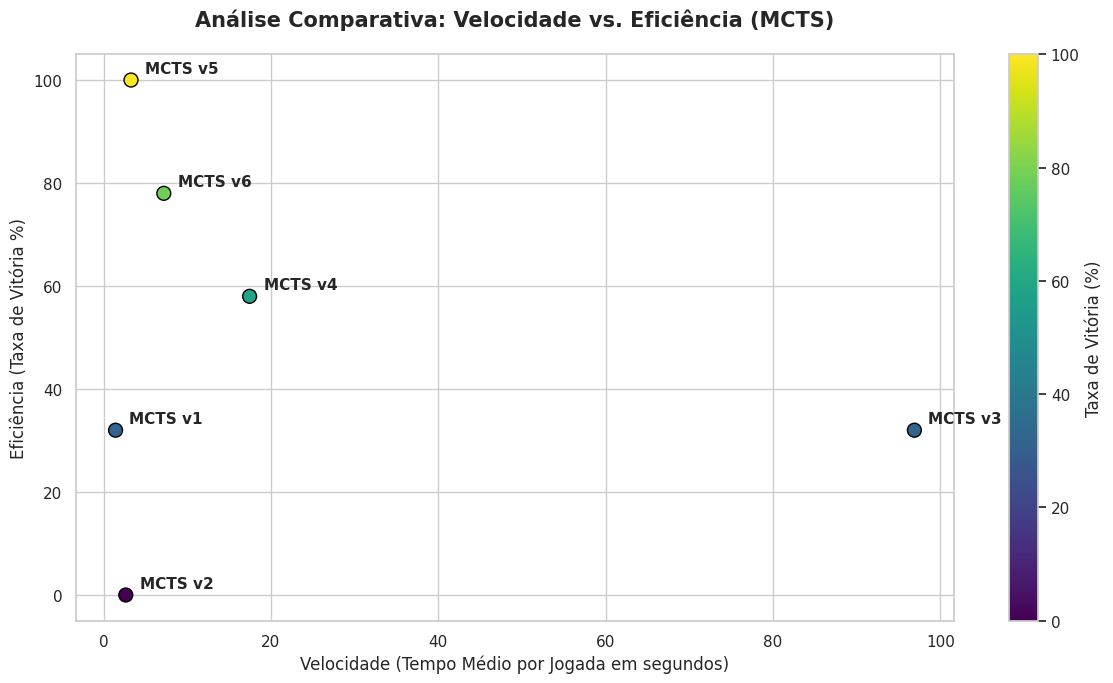

In [32]:
# =============================================================
# CÉLULA: GRÁFICO VELOCIDADE VS EFICIÊNCIA (MCTS)
# =============================================================

def gerar_grafico_velocidade_eficiencia(resultados):
    if not resultados:
        print("Sem dados disponíveis.")
        return

    # 1. Agregar dados por versão
    stats = {}
    for r in resultados:
        for ia_key, tempo_key, v_key in [('ia1', 'tempo_ia1', 'v_ia1'), ('ia2', 'tempo_ia2', 'v_ia2')]:
            nome = r[ia_key]
            if nome not in stats:
                stats[nome] = {'tempos': [], 'vitorias': 0, 'jogos': 0}
            
            stats[nome]['tempos'].append(r[tempo_key])
            stats[nome]['vitorias'] += r[v_key]
            stats[nome]['jogos'] += (r['v_ia1'] + r['v_ia2'] + r['empates'])

    # 2. Preparar listas para o gráfico
    nomes = []
    tempos_medios = []
    taxas_vitoria = []

    for nome, s in stats.items():
        nomes.append(nome)
        tempos_medios.append(np.mean(s['tempos']))
        taxas_vitoria.append((s['vitorias'] / s['jogos']) * 100)

    # 3. Criar o gráfico
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Desenhar os pontos
    scatter = plt.scatter(tempos_medios, taxas_vitoria, s=100, c=taxas_vitoria, cmap='viridis', edgecolors='black', zorder=3)
    
    # Adicionar anotações para cada ponto
    for i, nome in enumerate(nomes):
        plt.annotate(nome, (tempos_medios[i], taxas_vitoria[i]), 
                     xytext=(10, 5), textcoords='offset points', fontsize=11, fontweight='bold')

    # Configurações de eixos e títulos
    plt.title('Análise Comparativa: Velocidade vs. Eficiência (MCTS)', fontsize=15, pad=20, fontweight='bold')
    plt.xlabel('Velocidade (Tempo Médio por Jogada em segundos)', fontsize=12)
    plt.ylabel('Eficiência (Taxa de Vitória %)', fontsize=12)
    
    # Inverter o eixo X para que a "Velocidade" (mais rápido) fique à direita (opcional)
    # plt.gca().invert_xaxis() 

    # Adicionar uma barra de cor para escala de eficiência
    plt.colorbar(scatter, label='Taxa de Vitória (%)')
    
    plt.tight_layout()
    plt.show()

# Gerar o gráfico
gerar_grafico_velocidade_eficiencia(historico_resultados)

Com base neste gráfico de "Velocidade vs Eficiência" podemos concluir com clareza a evolução da eficiência dos nossos algoritmos ao longo do projeto. Neste gráfico, o desempenho ideal situa-se no canto superior esquerdo, onde se cruzam a alta taxa de vitória (eficiência) e o baixo tempo de resposta (velocidade).

O grande destaque do gráfico é o MCTS5, que se situa no patamar mais alto da taxa de Vitória (100%), mantendo um dos tempos de execução mais baixos entre as restantes versões. Esta versão localiza-se isolado no canto superior esquerdo, com a melhor performance disparado, o que comprova que a decisão de extrair os "instintos" de ataque e defesa para fora da árvore de pesquisa foi a solução mais equilibrada, garantindo uma inteligência superior sem o custo computacional de simulações excessivamente complexas.

Em contrapartida, a versão 3 localiza-se no extremo direito do gráfico, ilustrando como a complexidade quadrática torna o desempenho insustentável. Com um tempo de 97 segundos/jogada e uma eficiência que não acompanha esse esforço, ela fica muito distante do objetivo de otimização.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------DISCUSSÃO DE RESULTADOS-------
</h1>

In [20]:
# =============================================================
# CÉLULA: TABELA DE DESEMPENHO GLOBAL (Dinâmica)
# =============================================================
def gerar_tabela_classificacao(resultados):
    if not resultados:
        print("Sem dados para gerar a tabela. Corre os torneios primeiro!")
        return
    
    # 1. Dicionário para guardar as estatísticas acumuladas de cada IA
    stats = {}
    
    for r in resultados:
        ia1 = r['ia1']
        ia2 = r['ia2']
        
        # Criar entrada para a IA se ainda não existir
        if ia1 not in stats:
            stats[ia1] = {'Jogos': 0, 'Vitórias': 0, 'Derrotas': 0, 'Empates': 0}
        if ia2 not in stats:
            stats[ia2] = {'Jogos': 0, 'Vitórias': 0, 'Derrotas': 0, 'Empates': 0}
            
        # Calcular total de jogos neste torneio
        jogos_torneio = r['v_ia1'] + r['v_ia2'] + r['empates']
        
        # Somar estatísticas para a IA 1
        stats[ia1]['Jogos'] += jogos_torneio
        stats[ia1]['Vitórias'] += r['v_ia1']
        stats[ia1]['Derrotas'] += r['v_ia2']
        stats[ia1]['Empates'] += r['empates']
        
        # Somar estatísticas para a IA 2 (inverso)
        stats[ia2]['Jogos'] += jogos_torneio
        stats[ia2]['Vitórias'] += r['v_ia2']
        stats[ia2]['Derrotas'] += r['v_ia1']
        stats[ia2]['Empates'] += r['empates']

    # 2. Transformar os dados do dicionário numa lista para o Pandas
    dados_tabela = []
    for ia, s in stats.items():
        taxa_vitoria = (s['Vitórias'] / s['Jogos']) * 100 if s['Jogos'] > 0 else 0
        dados_tabela.append([
            ia, s['Jogos'], s['Vitórias'], s['Derrotas'], s['Empates'], taxa_vitoria
        ])
        
    # 3. Criar o DataFrame
    df = pd.DataFrame(dados_tabela, columns=["Versão MCTS", "Jogos", "Vitórias", "Derrotas", "Empates", "Taxa de Vitória"])
    
    # 4. Ordenar quem tem mais vitórias para o topo
    df = df.sort_values(by=["Vitórias", "Taxa de Vitória"], ascending=[False, False]).reset_index(drop=True)
    
    # 5. Formatar a tabela para ficar com um aspeto de "ranking"
    df.index = [f"{i+1}º" for i in range(len(df))]
    df.index.name = "Posição"
    df["Taxa de Vitória"] = df["Taxa de Vitória"].apply(lambda x: f"{x:.1f}%")
    
    # 6. Mostrar no ecrã
    display(HTML("<h3> Classificação Global do Torneio</h3>"))
    display(df)

# Chamar a função e passar a tua lista de resultados
gerar_tabela_classificacao(historico_resultados)

,Versão MCTS,Jogos,Vitórias,Derrotas,Empates,Taxa de Vitória
Posição,,,,,,
1º,MCTS v5,50,50,0,0,100.0%
2º,MCTS v6,50,39,11,0,78.0%
3º,MCTS v4,50,29,21,0,58.0%
4º,MCTS v1,50,16,34,0,32.0%
5º,MCTS v3,50,16,34,0,32.0%
6º,MCTS v2,50,0,50,0,0.0%


Cada versão do Monte Carlo Tree Search realizou 50 jogos, 10 jogos contra cada versão. Após a comparação entre as seis variantes, é possível observar uma evolução clara na eficiência dos algoritmos, com destaque para as versões MCTS5 e MCTS6. 

Uma das maiores surpresas foi o fraco desempenho da versão 2, que não obteve qualquer vitória nos 50 jogos realizados (com uma Taxa de Vitória de 0.0%), perdendo de forma desastrosa para o MCTS1 (rollout puramente aleatório). Este resultado demonstra que no algoritmo, a quantidade de simulações muitas vezes supera a implementação de heurísticas se estas não forem eficientes, o tempo computacional que a versão 2 gastou a inspecionar o tabuleiro "roubou-lhe" iterações vitais.

No caso do MCTS3, ficou demonstrado que o foco estrito na sobrevivência gera uma sobrecarga computacional excessiva. Com uma complexidade algorítmica de O(n^2), o tempo médio disparou para os 96.9 segundos por jogada. Esta lentidão reduziu drasticamente o número de simulações calculadas, deixando a árvore de pesquisa "míope" e incapaz de avaliar o jogo em profundidade. O impacto estatístico foi evidente: a inteligência da MCTS3 não compensou a perda de velocidade, terminando empatada com versão clássica do MCTS, ambas com uma taxa de vitória de apenas 32.0%.

A MCTS4 ficou em 3º lugar na classificação com uma taxa de vitória de 58.0%. Esta variante venceu das primeiras 3 versões com bastante facilidade, registando 9 vitorias em 10 jogos contra a MCTS1 e MCTS3, por outro lado evidenciou fortes limitações de raciocínio perante as versões 5 e 6, que acabou perdendo por 0-10 contra o MCTS5 e 1-9 para o MCTS6.

No topo da classificação, a MCTS5 destacou-se como a variante mais eficiente, alcançando um total de 50 vitórias em 50 jogos possíveis (taxa de sucesso de 100%). A refatorização da sua lógica para uma complexidade linear (O(n)), aliada à extração dos instintos de ataque e defesa para fora da árvore de pesquisa, tornou esta iteração altamente precisa e computacionalmente veloz, com uma média de apenas 3.27 segundos por jogada. De forma notável, a MCTS5 superou a MCTS6 por 10-0 no confronto direto. Embora a versão 6 utilize paralelismo massivo o que lhe garantiu o 2º lugar na classificação geral com 78% de vitórias, os resultados indicam que a precisão tática da MCTS5 é significativamente superior à força computacional bruta, adaptando-se com maior rigor à dinâmica do jogo.


In [21]:
# =============================================================
# CÉLULA: TABELA DE COMPLEXIDADE E TEMPO (Dinâmica + Jogadas)
# =============================================================
def gerar_tabela_complexidade(resultados):
    if not resultados:
        print("Sem dados para gerar a tabela.")
        return

    # 1. Dicionário apenas com a complexidade (removemos as jogadas fixas)
    info_estatica = {
        "MCTS v1": {"comp": "O(n)"},
        "MCTS v2": {"comp": "O(n)"},
        "MCTS v3": {"comp": "O(n²)"},
        "MCTS v4": {"comp": "O(n)"},
        "MCTS v5": {"comp": "O(n)"},
        "MCTS v6": {"comp": "O(n)"}
    }

    # 2. Extrair os tempos e somar as jogadas REAIS da tua lista
    tempos_acumulados = {}
    jogadas_acumuladas = {} # <-- Novo dicionário para acumular as jogadas
    
    for r in resultados:
        ia1, ia2 = r['ia1'], r['ia2']
        
        # Inicializar as chaves se a IA aparecer pela primeira vez
        if ia1 not in tempos_acumulados: tempos_acumulados[ia1] = []
        if ia2 not in tempos_acumulados: tempos_acumulados[ia2] = []
        
        if ia1 not in jogadas_acumuladas: jogadas_acumuladas[ia1] = 0
        if ia2 not in jogadas_acumuladas: jogadas_acumuladas[ia2] = 0
            
        # Adicionar os tempos médios deste torneio específico
        if r['tempo_ia1'] > 0: tempos_acumulados[ia1].append(r['tempo_ia1'])
        if r['tempo_ia2'] > 0: tempos_acumulados[ia2].append(r['tempo_ia2'])
            
        # Acumular o total de jogadas do torneio para ambas as IAs envolvidas
        jogadas_acumuladas[ia1] += r['total_jogadas']
        jogadas_acumuladas[ia2] += r['total_jogadas']

    # 3. Construir os dados para o Pandas
    dados_tabela = []
    for ia, lista_tempos in tempos_acumulados.items():
        # Calcular a média de tempo
        tempo_real = sum(lista_tempos) / len(lista_tempos) if lista_tempos else 0
        
        # Buscar a complexidade estática
        complexidade = info_estatica.get(ia, {}).get("comp", "-")
        
        # Buscar o total de jogadas calculado dinamicamente
        total_jogadas_ia = jogadas_acumuladas.get(ia, 0)
        
        dados_tabela.append([ia, complexidade, tempo_real, total_jogadas_ia])

    # 4. Criar e formatar o DataFrame
    df_comp = pd.DataFrame(dados_tabela, columns=[
        "Versão", "Complexidade", "Tempo Médio/Jogada", "Total de Jogadas"
    ])
    
    # Ordenar pelo nome da Versão (v1, v2, v3...)
    df_comp = df_comp.sort_values(by="Versão").reset_index(drop=True)
    
    # Formatar o tempo para mostrar apenas 4 casas decimais e o "s" de segundos
    df_comp["Tempo Médio/Jogada"] = df_comp["Tempo Médio/Jogada"].apply(lambda x: f"{x:.4f} s")
    df_comp = df_comp.set_index("Versão")

    # 5. Mostrar no ecrã
    display(HTML("<h3> Análise de Complexidade Computacional e Tempos de Execução</h3>"))
    display(df_comp)

# Chamar a função
gerar_tabela_complexidade(historico_resultados)

,Complexidade,Tempo Médio/Jogada,Total de Jogadas
Versão,,,
MCTS v1,O(n),1.4236 s,876
MCTS v2,O(n),2.6445 s,1442
MCTS v3,O(n²),96.9034 s,907
MCTS v4,O(n),17.4461 s,1322
MCTS v5,O(n),3.2690 s,911
MCTS v6,O(n),7.1877 s,1310


A análise à complexidade e aos tempos de execução demonstra na perfeição como as escolhas de arquitetura afetam a performance do algoritmo. O caso mais chocante é o da MCTS v3: ao tentar prever exaustivamente as respostas do adversário, a sua complexidade aumentou para O(n^2), resultando num tempo médio de 96.9 segundos por jogada.

Em contrapartida, as otimizações introduzidas a partir da MCTS v4 permitiram reduzir novamente a pesquisa para uma complexidade linear (O(n)). Dentro deste grupo, a MCTS v5 destaca-se como a versão mais equilibrada, combinando inteligência tática com uma rapidez excecional (apenas 3.26 segundos por jogada). Já a MCTS v6, apesar de ser veloz (7.18 segundos), regista um tempo ligeiramente superior ao da v5. Isto acontece devido ao overhead inerente à paralelização, ou seja, a fração de tempo gasta pelo sistema apenas a preparar e distribuir as simulações pelos vários núcleos do processador.

Por último, o total de jogadas de cada versão mostra nos uma visão fascinante sobre a própria dinâmica das partidas. O facto de as versões v2, v4 e v6 ultrapassarem as 1300 jogadas acumuladas mostra que estas IAs protagonizam confrontos muito mais longos e disputados. Os seus instintos defensivos apurados bloqueiam vitórias fáceis, obrigando as partidas a prolongarem-se até às fases mais avançadas do tabuleiro.

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------CONCLUSÃO-------
</h1>



Ao decorrer deste trabalho, exploraram‑se seis variantes do algoritmo Monte Carlo Tree Search para o jogo PopOut, bem como uma abordagem baseada numa árvore de decisão ID3. Os resultados mostram que o equilíbrio entre inteligência heurística e velocidade computacional é o fator mais crítico para o sucesso do agente. 

A versão MCTS2, que tentava inspecionar o tabuleiro à procura de vitórias imediatas, não obteve qualquer vitória nos cinquenta jogos disputados, a sobrecarga de tempo que introduziu reduziu drasticamente o número de simulações, tornando‑a menos eficaz do que a versão base puramente aleatória. Já a MCTS3, focada em evitar todas as respostas vitoriosas do adversário, revelou uma complexidade quadrática que a tornou extremamente lenta, com quase 97 segundos/jogada, e empatou estatisticamente com a versão clássica. 

A inclusão de um “filtro de segurança” na MCTS4 melhorou os resultados, mas a versão que se destacou mais foi o MCTS5, ao extrair os instintos de ataque e defesa para fora da árvore de pesquisa, mantendo a complexidade linear e alcançando 100% de vitórias. A versão MCTS6, embora rápida, não conseguiu superar a precisão tática da MCTS5 no confronto direto, evidenciando que uma heurística bem precisa pode valer mais do que força bruta computacional. 

Quanto à árvore de decisão ID3, registou uma precisão modesta de cerca de 19%, o que não representa uma falha de aprendizagem, mas sim a dificuldade inerente a jogos de sequência, uma decisão ótima raramente depende apenas do estado estático do tabuleiro, exigindo simulação de cenários futuros. 

Em síntese, este estudo demonstra que, no PopOut, a eficácia de um agente de IA resulta de uma arquitetura que combine simulações rápidas com heurísticas simples e oportunistas, deixando claro que “pensar depressa” pode ser mais vantajoso do que “pensar demasiado”